In [3]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "src").exists() else cwd.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import yaml
from src.dsge import DSGE


cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "src").exists() else cwd.parent


def correr_dsge_yaml(config_path, seed=1234):
    config_path = Path(config_path)
    if not config_path.is_absolute():
        config_path = ROOT / config_path

    cfg = yaml.safe_load(config_path.read_text(encoding="utf-8"))
    model, registry, theta = DSGE.from_yaml(config_path)

    data_path = Path(cfg["data"]["path"])
    if not data_path.is_absolute():
        data_path = ROOT / data_path

    Y = (
        pd.read_csv(data_path)
        .loc[:, cfg["data"]["columns"]]
        .to_numpy(dtype=float)
    )

    map_cfg = cfg["map"]
    mcmc_cfg = {
        key: value
        for key, value in cfg["mcmc"].items()
        if key not in {"enabled", "draws"}
    }

    results = model.compute(
        registry=registry,
        theta_struct=theta,
        data=Y,
        compute_steady=cfg["steady"]["enabled"],
        div=cfg["solver"]["div"],
        likelihood_kwargs={
            "initial_covariance": cfg["likelihood"]["initial_covariance"],
            "diffuse_scale": cfg["likelihood"]["diffuse_scale"],
        },
        map=map_cfg["enabled"],
        map_bounds=map_cfg["bounds"],
        map_kwargs={
            "method": map_cfg["method"],
            "hess_step": map_cfg["hess_step"],
            "tau_scale": map_cfg["tau_scale"],
            "hessian_strategy": map_cfg["hessian_strategy"],
            "include_jacobian_prior":
                map_cfg["include_jacobian_prior"],
        },
        run_mcmc=cfg["mcmc"]["enabled"],
        mcmc_draws=cfg["mcmc"]["draws"],
        mcmc_rng=np.random.default_rng(seed),
        mcmc_kwargs=mcmc_cfg,
        log_summary=True,
    )

    irf_cfg = cfg["irf"]

    irfs = model.impulse_responses(
        horizon=irf_cfg["horizon"],
        quantiles=irf_cfg["quantiles"],
        shock_scale=irf_cfg["shock_scale"],
        div=cfg["solver"]["div"],
        plot=True,
    )

    return {
        "model": model,
        "registry": registry,
        "results": results,
        "irfs": irfs,
        "data": Y,
        "config": cfg,
    }

MAP success: True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
MAP optimization Complete: Starting Metropolis Hastings

[adapt] it=500 rate=0.000 scale=1.000e-02
[adapt] it=1000 rate=0.432 scale=1.500e-03
[Inference] it=1500 rate=0.296 scale=1.500e-03
[Inference] it=2000 rate=0.296 scale=1.500e-03
[Inference] it=2500 rate=0.296 scale=1.500e-03
[Metropolis] acceptance rate: 0.221 (552/2500) scale=1.500e-03

[DSGE.compute] summary
  MCMC acceptance rate: 0.221 (552/2500)


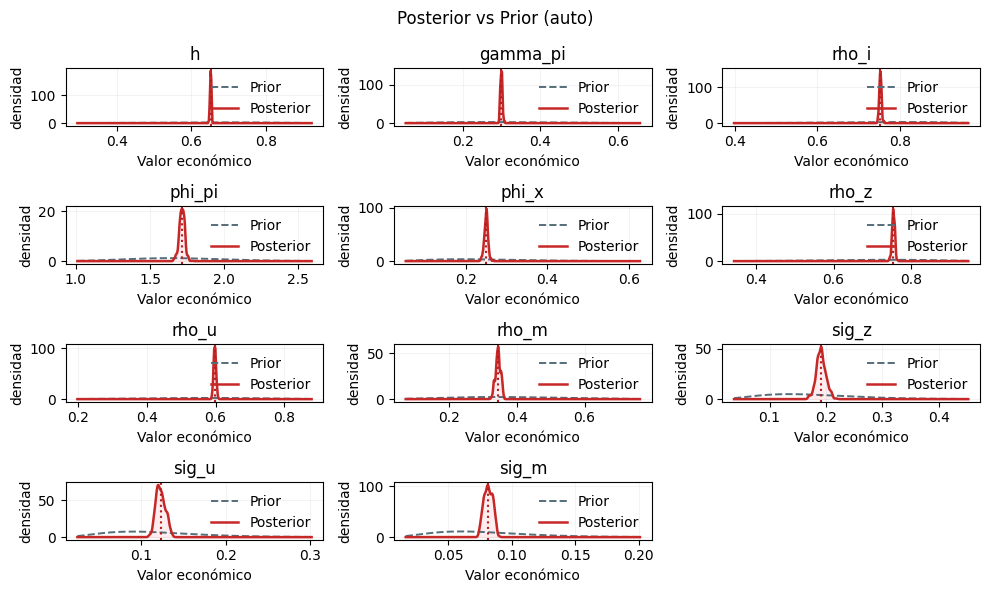

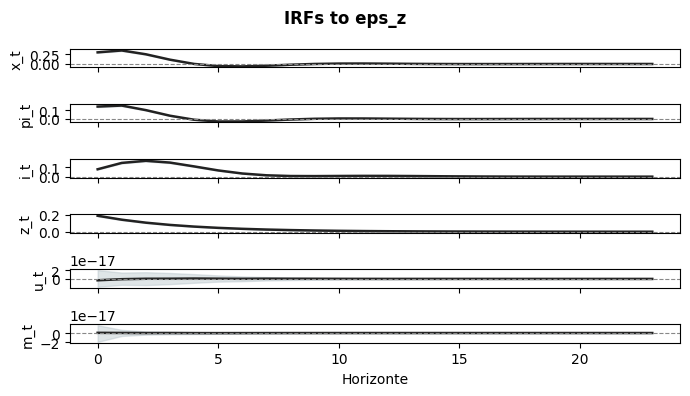

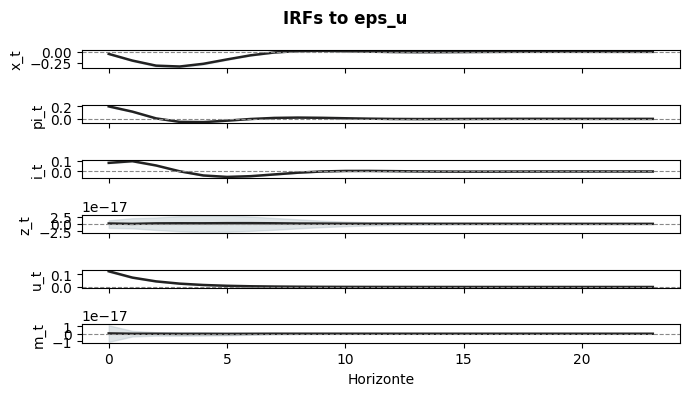

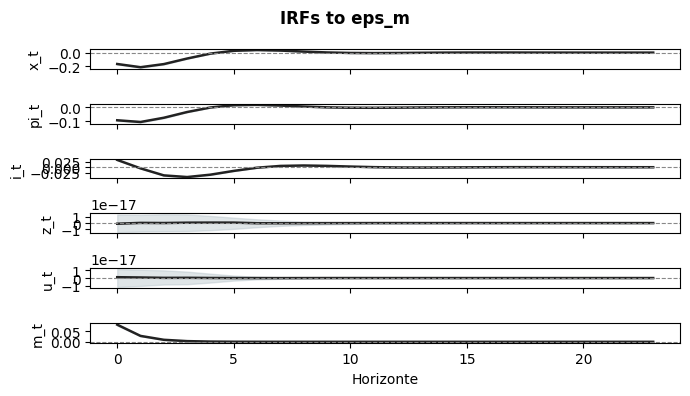

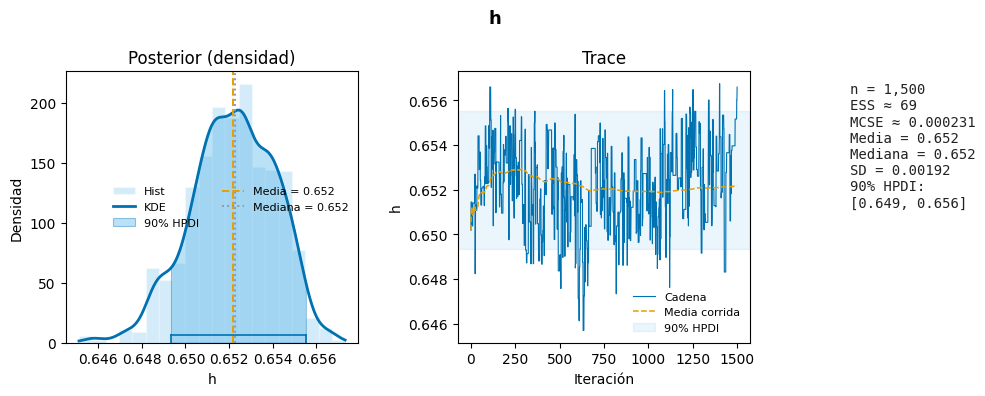

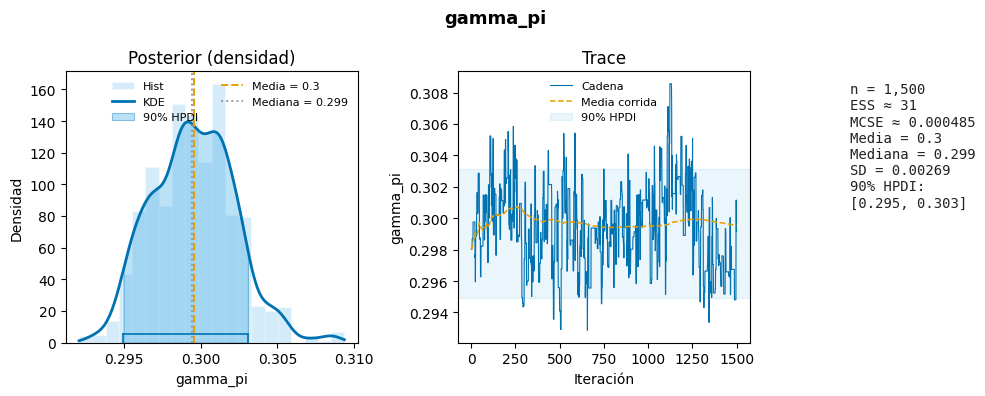

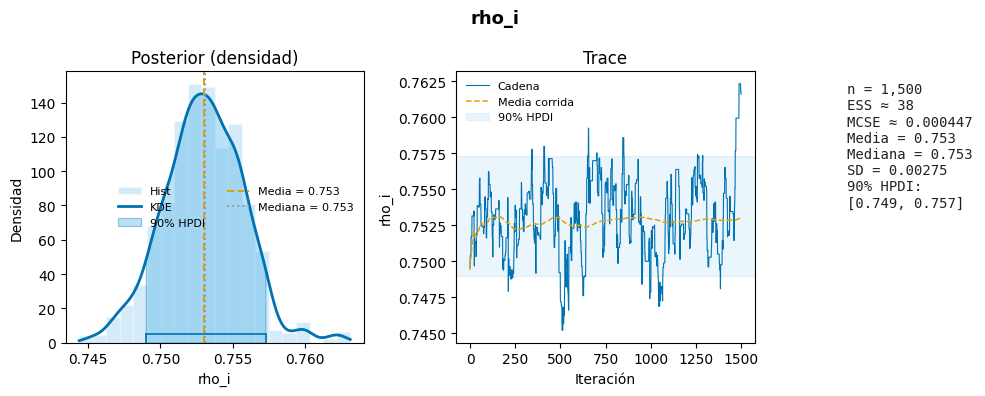

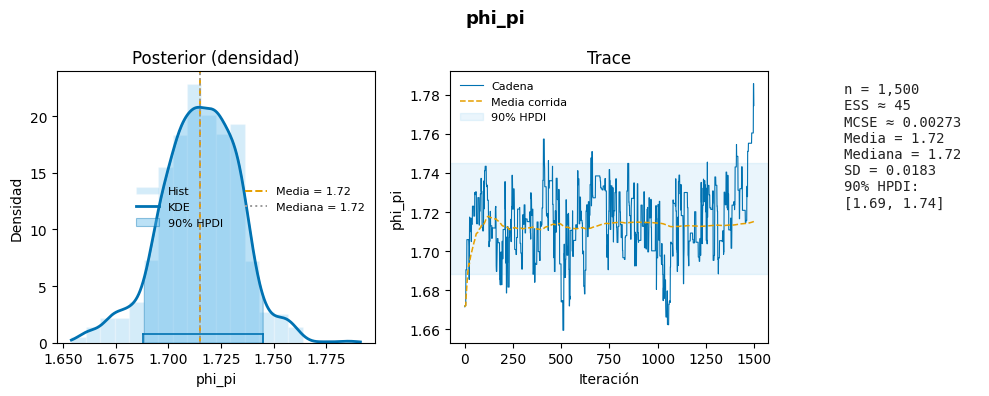

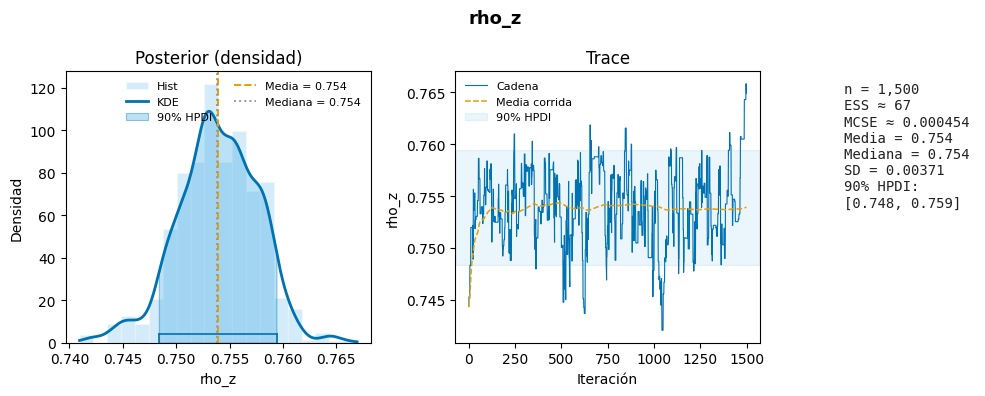

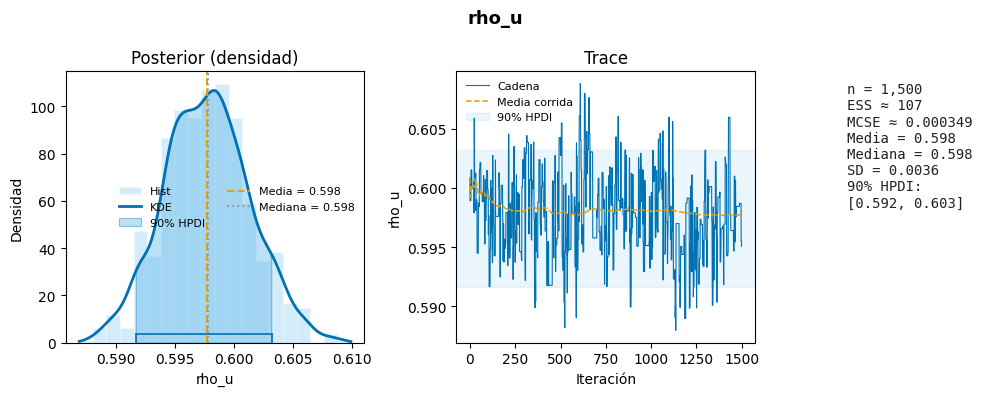


Posterior (espacio económico) | draws usados: 1500/2500 (burn-in=1000) | tasa de aceptación: 0.221
            mean      std     25%     50%     75%
h         0.6522 0.001916   0.651  0.6523  0.6537
gamma_pi  0.2995  0.00269  0.2975  0.2994  0.3014
rho_i      0.753 0.002747  0.7513  0.7531  0.7549
phi_pi     1.715  0.01829   1.704   1.715   1.728
phi_x     0.2493 0.004767  0.2465  0.2498   0.252
rho_z     0.7539 0.003707  0.7517  0.7538  0.7565
rho_u     0.5977 0.003603  0.5951  0.5978  0.6001
rho_m      0.344 0.007572  0.3394  0.3442  0.3495
sig_z     0.1913 0.008334  0.1859  0.1911  0.1969
sig_u     0.1231 0.005472  0.1191  0.1226  0.1271
sig_m    0.08153 0.003396 0.07888 0.08147 0.08436


In [5]:
hybrid_nk = correr_dsge_yaml(
    "configs/hybrid_nk_medium.yaml",
    seed=20260714,
)

hybrid_nk["model"].analyze_posteriors(
    subset=["h", "gamma_pi", "rho_i", "phi_pi", "rho_z", "rho_u"],
    plot=True,
    describe=True,
)

MAP success: True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
MAP optimization Complete: Starting Metropolis Hastings

[adapt] it=500 rate=0.000 scale=1.000e-02
[adapt] it=1000 rate=0.508 scale=1.500e-03
[Inference] it=1500 rate=0.438 scale=1.500e-03
[Inference] it=2000 rate=0.416 scale=1.500e-03
[Inference] it=2500 rate=0.440 scale=1.500e-03
[Metropolis] acceptance rate: 0.310 (774/2500) scale=1.500e-03

[DSGE.compute] summary
  MCMC acceptance rate: 0.310 (774/2500)


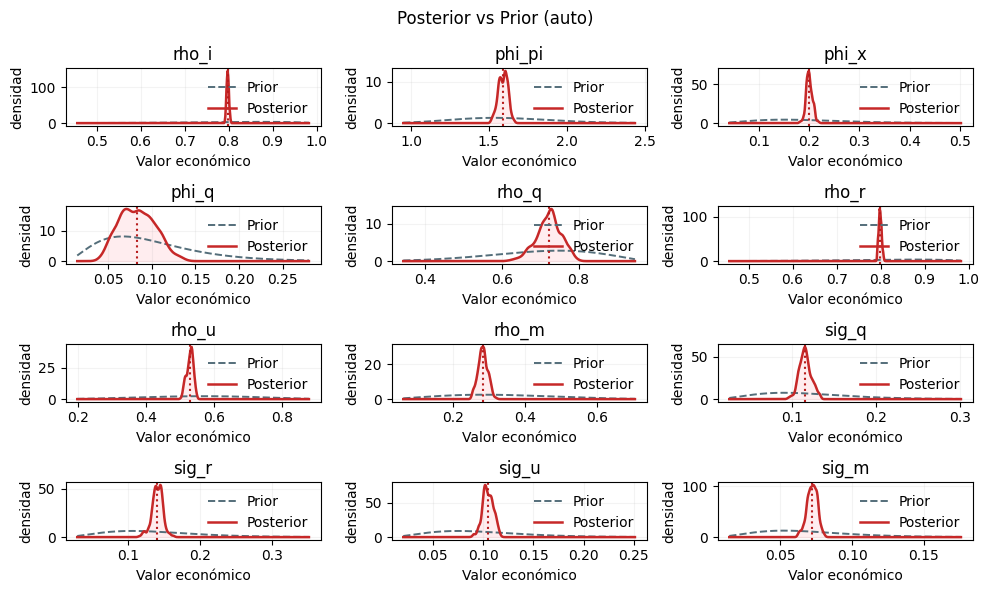

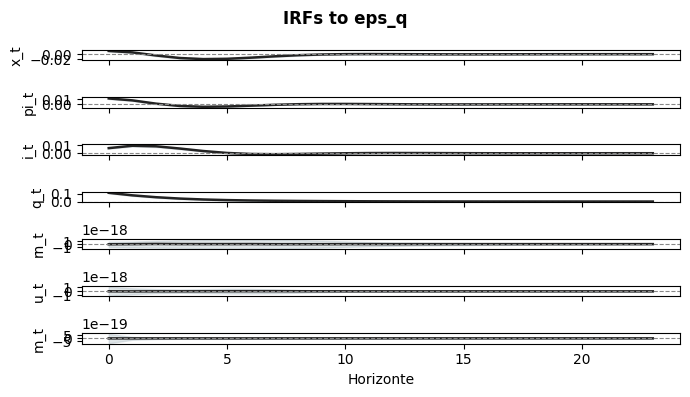

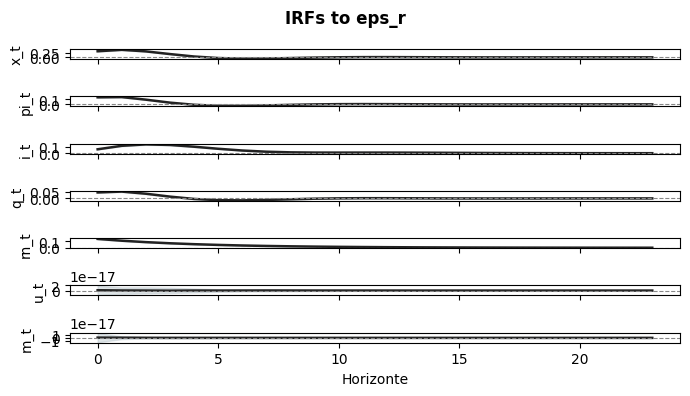

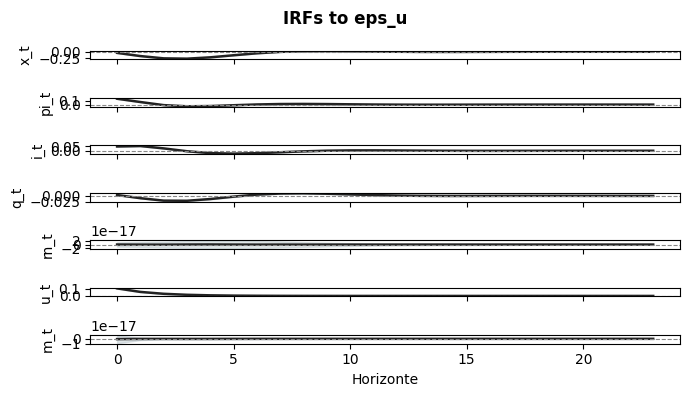

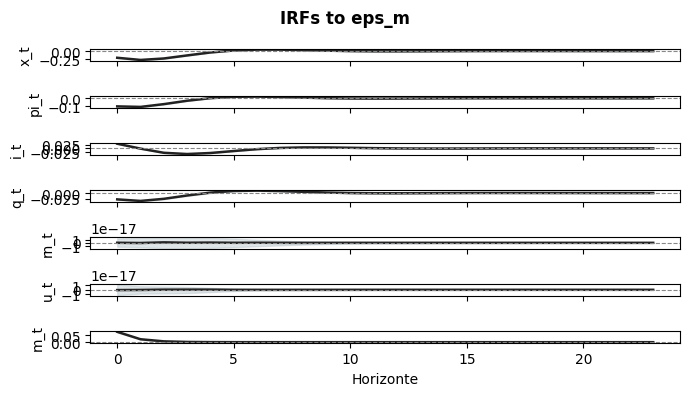

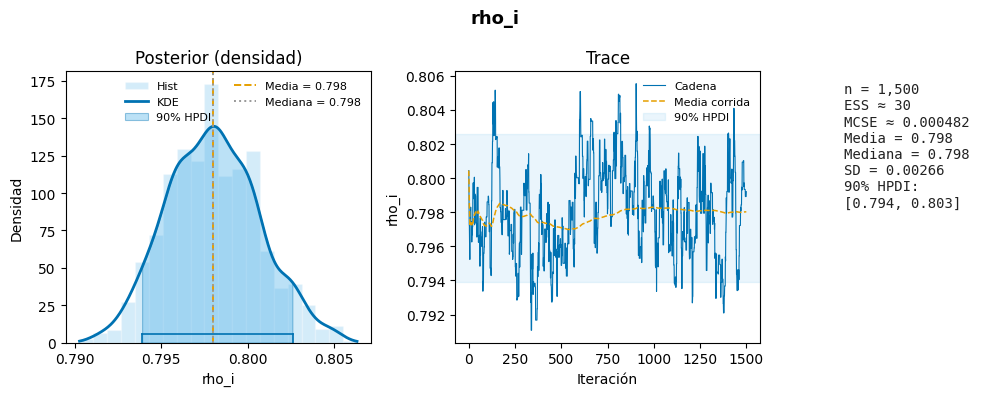

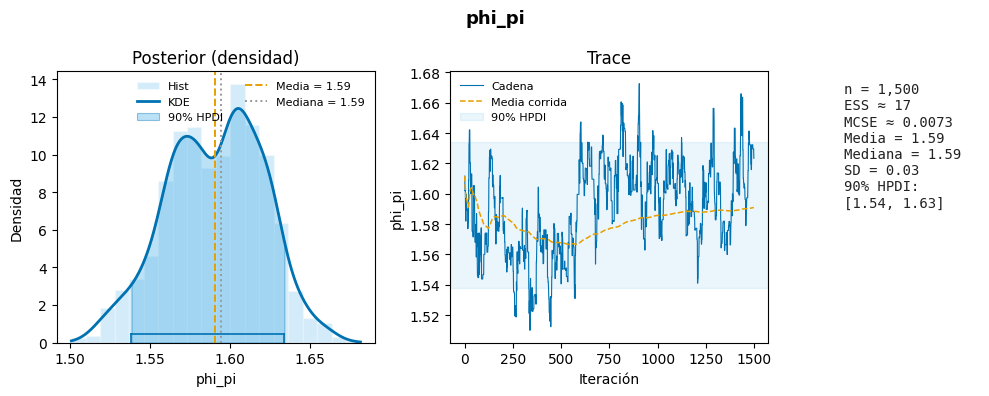

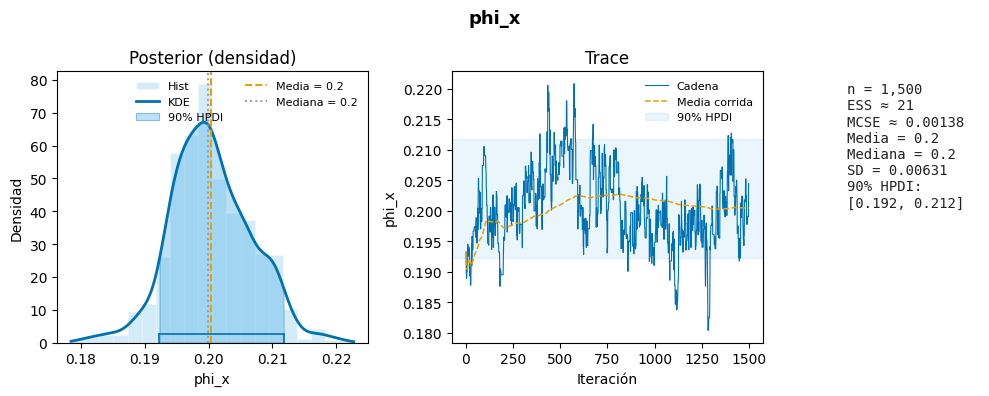

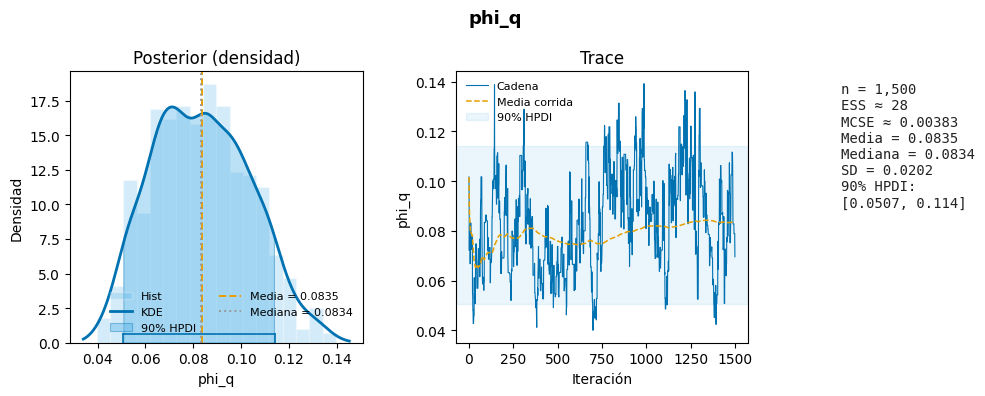

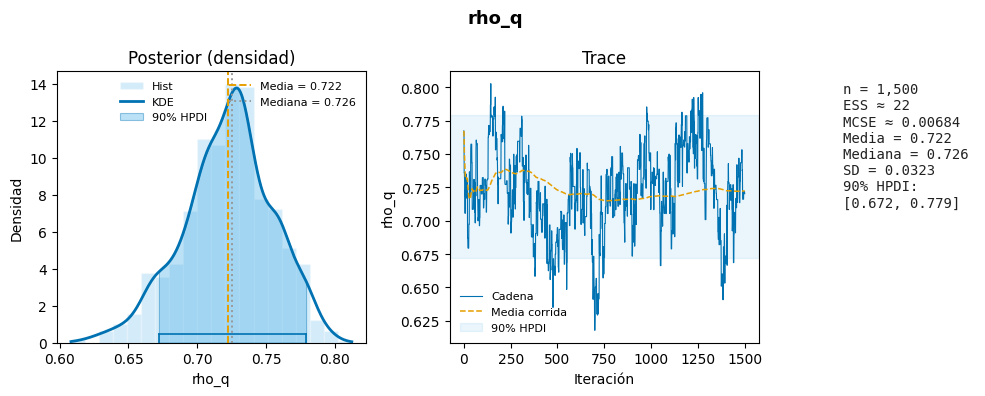

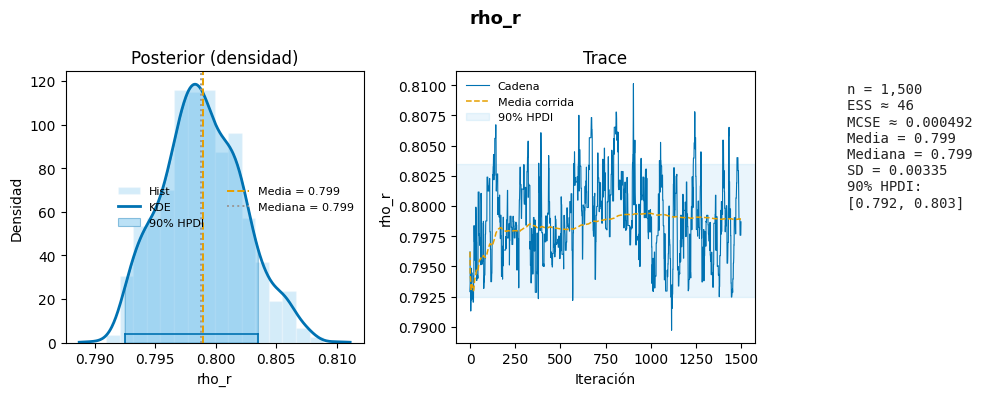


Posterior (espacio económico) | draws usados: 1500/2500 (burn-in=1000) | tasa de aceptación: 0.310
          mean      std     25%     50%     75%
rho_i    0.798 0.002656  0.7961   0.798  0.7999
phi_pi   1.591  0.02999   1.569   1.594   1.613
phi_x   0.2004 0.006307  0.1962     0.2  0.2047
phi_q  0.08354  0.02018 0.06815 0.08343 0.09826
rho_q   0.7222  0.03231   0.703  0.7256  0.7435
rho_r   0.7989 0.003345  0.7966  0.7988  0.8012
rho_u   0.5294 0.009909  0.5229  0.5305  0.5363
rho_m    0.283  0.01326  0.2745  0.2825   0.292
sig_q   0.1154  0.00712  0.1108   0.115  0.1196
sig_r   0.1404  0.00756   0.136  0.1408  0.1455
sig_u   0.1049 0.005283  0.1015  0.1045  0.1087
sig_m  0.07216 0.003559 0.06972 0.07236 0.07487


In [6]:
open_nk = correr_dsge_yaml(
    "configs/open_economy_nk.yaml",
    seed=20260715,
)

open_nk["model"].analyze_posteriors(
    subset=["rho_i", "phi_pi", "phi_x", "phi_q", "rho_q", "rho_r"],
    plot=True,
    describe=True,
)